# NYC Shootings Cluster Analysis

## Index

[1. Importing Libraries](#1-importing-libraries)

[2. Loading Dataset](#2-loading-dataset)

[3. Data Dictionary](#3-data-dictionary)

[4. Information of the Data](#4-information-of-the-data)

[5. Preprocessing (Cleaning)](#5-preprocessing-cleaning)

&emsp;[5.1 Cleaning PERP_AGE_GROUP — Erroneous Values](#51-cleaning-perp_age_group--erroneous-values)

&emsp;[5.2 Cleaning VIC_AGE_GROUP](#52-cleaning-vic_age_group)

&emsp;[5.3 Filling Missing Categorical Values](#53-filling-missing-categorical-values)

&emsp;[5.4 Dropping Rows Without Coordinates](#54-dropping-rows-without-coordinates)

&emsp;[5.5 Date and Time Feature Extraction](#55-date-and-time-feature-extraction)

&emsp;[5.6 Drop Redundant Columns](#56-drop-redundant-columns)

[6. Exploratory Data Analysis (EDA)](#6-exploratory-data-analysis-eda)

&emsp;[6.1 Univariate Analysis](#61-univariate-analysis)

&emsp;[6.2 Bivariate Analysis](#62-bivariate-analysis)

[7. Feature Engineering](#7-feature-engineering)

[8. Handling Missing Data (Imputation)](#8-handling-missing-data-imputation)

[9. Clustering Model Development](#9-clustering-model-development)

&emsp;[9.1 K-Means Clustering](#91-k-means-clustering)

&emsp;[9.2 Agglomerative Hierarchical Clustering](#92-agglomerative-hierarchical-clustering)

&emsp;[9.3 DBSCAN Clustering](#93-dbscan-clustering)

&emsp;[9.4 Model Comparison and Best Model Selection](#94-model-comparison-and-best-model-selection)

[10. Geographical Visualization on NYC Map](#10-geographical-visualization-on-nyc-map)

[11. Conclusion and Recommendations](#11-conclusion-and-recommendations)


## 1. Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Encoding
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Cluster Evaluation Metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Hierarchical Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# 3D plotting
from mpl_toolkits.mplot3d import Axes3D

# Geographical Visualization
import folium
from folium.plugins import MarkerCluster, HeatMap

pd.set_option('display.max_columns', None)
print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Loading Dataset

In [ ]:
nysho = pd.read_csv('Dataset.csv')
print(f"Dataset loaded successfully.")
print(f"Shape: {nysho.shape[0]:,} rows × {nysho.shape[1]} columns")
nysho.head()

Dataset loaded successfully.
Shape: 27,312 rows × 21 columns


,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,STATISTICAL_MURDER_FLAG,PERP_AGE_GROUP,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
0,228798151,05/27/2021,21:30:00,QUEENS,NaN,105,0.0,NaN,NaN,False,NaN,NaN,NaN,18-24,M,BLACK,1.058925e+06,180924.000000,40.662965,-73.730839,POINT (-73.73083868899994 40.662964620000025)
1,137471050,06/27/2014,17:40:00,BRONX,NaN,40,0.0,NaN,NaN,False,NaN,NaN,NaN,18-24,M,BLACK,1.005028e+06,234516.000000,40.810352,-73.924942,POINT (-73.92494232599995 40.81035186300006)
2,147998800,11/21/2015,03:56:00,QUEENS,NaN,108,0.0,NaN,NaN,True,NaN,NaN,NaN,25-44,M,WHITE,1.007668e+06,209836.531250,40.742607,-73.915492,POINT (-73.91549174199997 40.74260663300004)
3,146837977,10/09/2015,18:30:00,BRONX,NaN,44,0.0,NaN,NaN,False,NaN,NaN,NaN,<18,M,WHITE HISPANIC,1.006537e+06,244511.140625,40.837782,-73.919457,POINT (-73.91945661499994 40.83778200300003)
4,58921844,02/19/2009,22:58:00,BRONX,NaN,47,0.0,NaN,NaN,True,25-44,M,BLACK,45-64,M,BLACK,1.024922e+06,262189.406250,40.886238,-73.852910,POINT (-73.85290950899997 40.88623791800006)


## 3. Data Dictionary

| Column | Description |
|--------|-------------|
| `INCIDENT_KEY` | Randomly generated persistent ID for each arrest |
| `OCCUR_DATE` | Exact date of the shooting incident (MM/DD/YYYY) |
| `OCCUR_TIME` | Exact time of the shooting incident (HH:MM:SS) |
| `BORO` | Borough where the shooting incident occurred (BRONX, BROOKLYN, MANHATTAN, QUEENS, STATEN ISLAND) |
| `LOC_OF_OCCUR_DESC` | Whether the shooting occurred INSIDE or OUTSIDE |
| `PRECINCT` | Precinct where the shooting incident occurred |
| `JURISDICTION_CODE` | Jurisdiction: 0 = Patrol, 1 = Transit, 2 = Housing (NYPD); ≥3 = Non-NYPD |
| `LOC_CLASSFCTN_DESC` | Location classification (STREET, HOUSING, DWELLING, VEHICLE, COMMERCIAL, etc.) |
| `LOCATION_DESC` | Specific location of the shooting incident |
| `STATISTICAL_MURDER_FLAG` | True if the shooting resulted in the victim's death (counted as murder) |
| `PERP_AGE_GROUP` | Perpetrator's age within a category |
| `PERP_SEX` | Perpetrator's sex (M / F / U) |
| `PERP_RACE` | Perpetrator's race description |
| `VIC_AGE_GROUP` | Victim's age within a category |
| `VIC_SEX` | Victim's sex (M / F / U) |
| `VIC_RACE` | Victim's race description |
| `X_COORD_CD` | Midblock X-coordinate — NY State Plane, Long Island Zone, NAD 83 (feet, FIPS 3104) |
| `Y_COORD_CD` | Midblock Y-coordinate — NY State Plane, Long Island Zone, NAD 83 (feet, FIPS 3104) |
| `Latitude` | Latitude — WGS 1984, decimal degrees (EPSG 4326) |
| `Longitude` | Longitude — WGS 1984, decimal degrees (EPSG 4326) |
| `Lon_Lat` | Combined Longitude and Latitude point for mapping |


## 4. Information of the Data

In [ ]:
nysho.shape

(27312, 21)

In [ ]:
nysho.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27312 entries, 0 to 27311
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   INCIDENT_KEY             27312 non-null  int64  
 1   OCCUR_DATE               27312 non-null  object 
 2   OCCUR_TIME               27312 non-null  object 
 3   BORO                     27312 non-null  object 
 4   LOC_OF_OCCUR_DESC        1716 non-null   object 
 5   PRECINCT                 27312 non-null  int64  
 6   JURISDICTION_CODE        27310 non-null  float64
 7   LOC_CLASSFCTN_DESC       1716 non-null   object 
 8   LOCATION_DESC            12335 non-null  object 
 9   STATISTICAL_MURDER_FLAG  27312 non-null  bool   
 10  PERP_AGE_GROUP           17968 non-null  object 
 11  PERP_SEX                 18002 non-null  object 
 12  PERP_RACE                18002 non-null  object 
 13  VIC_AGE_GROUP            27312 non-null  object 
 14  VIC_SEX               

In [ ]:
nysho.head()

In [ ]:
# Statistical summary of all columns
nysho.describe(include='all')


In [ ]:
# Missing values per column
missing_counts = nysho.isnull().sum()
print("Missing values per column:")
display(missing_counts[missing_counts > 0].sort_values(ascending=False))


Missing values per column:


,0
LOC_OF_OCCUR_DESC,25596
LOC_CLASSFCTN_DESC,25596
LOCATION_DESC,14977
PERP_AGE_GROUP,9344
PERP_RACE,9310
PERP_SEX,9310
Longitude,10
Latitude,10
Lon_Lat,10
JURISDICTION_CODE,2


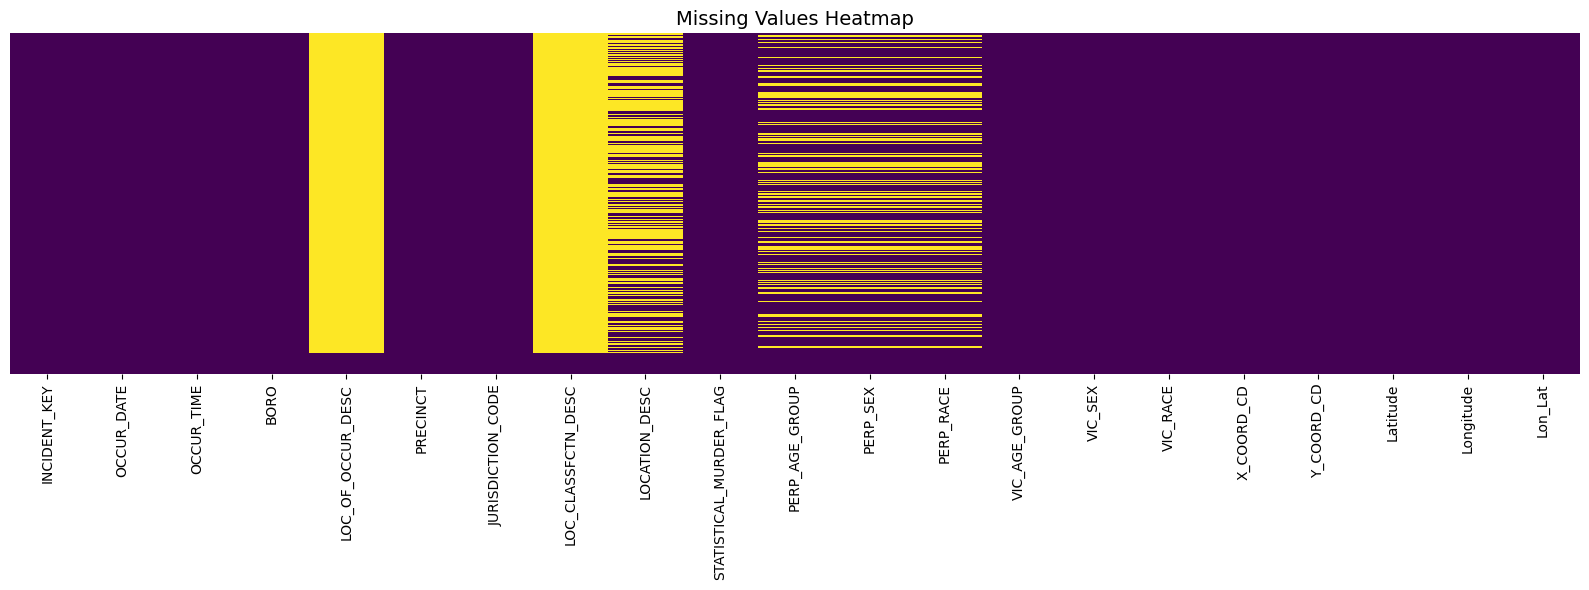

In [ ]:
# Missing Values Heatmap
plt.figure(figsize=(16, 6))
sns.heatmap(nysho.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap', fontsize=14)
plt.tight_layout()
plt.show()


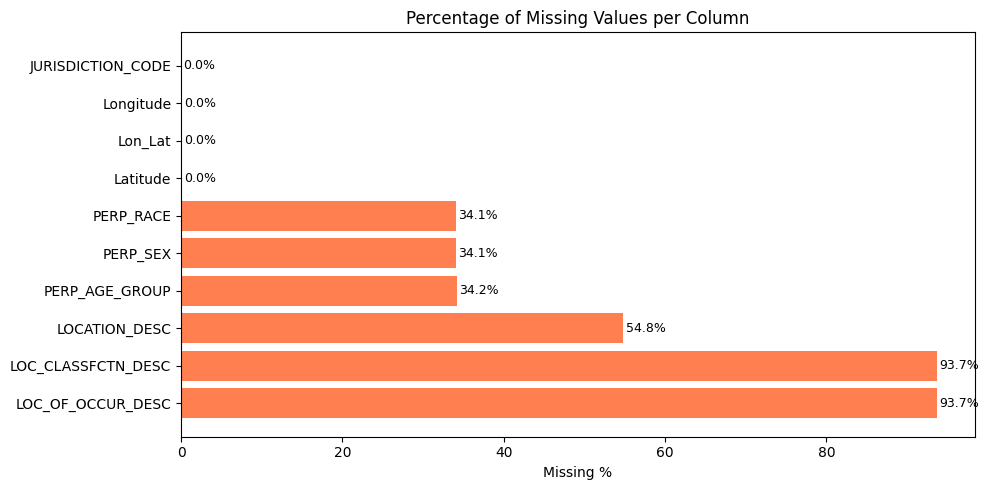

In [ ]:
# Percentage of missing values
missing_pct = (nysho.isnull().sum() / len(nysho) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10, 5))
bars = plt.barh(missing_pct.index, missing_pct.values, color='coral')
plt.xlabel('Missing %')
plt.title('Percentage of Missing Values per Column')
for bar, val in zip(bars, missing_pct.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 5. Preprocessing (Cleaning)

### 5.1 Cleaning PERP_AGE_GROUP



In [ ]:
# Valid age groups for reference
valid_age_groups = ['<18', '18-24', '25-44', '45-64', '65+', 'UNKNOWN']

print("PERP_AGE_GROUP before cleaning:")
print(nysho['PERP_AGE_GROUP'].value_counts(dropna=False))

# Replace invalid entries with NaN
invalid_perp_ages = ['940', '224', '1020', '(null)']
for val in invalid_perp_ages:
    nysho['PERP_AGE_GROUP'] = nysho['PERP_AGE_GROUP'].replace(val, np.nan)

print("\nPERP_AGE_GROUP after cleaning:")
print(nysho['PERP_AGE_GROUP'].value_counts(dropna=False))


PERP_AGE_GROUP before cleaning:
PERP_AGE_GROUP
NaN        9344
18-24      6222
25-44      5687
UNKNOWN    3148
<18        1591
(null)      640
45-64       617
65+          60
940           1
224           1
1020          1
Name: count, dtype: int64

PERP_AGE_GROUP after cleaning:
PERP_AGE_GROUP
NaN        9987
18-24      6222
25-44      5687
UNKNOWN    3148
<18        1591
45-64       617
65+          60
Name: count, dtype: int64


### 5.2 Cleaning VIC_AGE_GROUP



In [ ]:
print("VIC_AGE_GROUP before cleaning:")
print(nysho['VIC_AGE_GROUP'].value_counts(dropna=False))

nysho['VIC_AGE_GROUP'] = nysho['VIC_AGE_GROUP'].replace('1022', '45-64')

print("\nVIC_AGE_GROUP after cleaning:")
print(nysho['VIC_AGE_GROUP'].value_counts(dropna=False))


VIC_AGE_GROUP before cleaning:
VIC_AGE_GROUP
25-44      12281
18-24      10086
<18         2839
45-64       1863
65+          181
UNKNOWN       61
1022           1
Name: count, dtype: int64

VIC_AGE_GROUP after cleaning:
VIC_AGE_GROUP
25-44      12281
18-24      10086
<18         2839
45-64       1864
65+          181
UNKNOWN       61
Name: count, dtype: int64


### 5.3 Filling Missing Categorical Values




In [ ]:
# Columns to fill NaN with '(null)' placeholder
fill_null_cols = ['PERP_SEX', 'PERP_RACE', 'PERP_AGE_GROUP',
                  'LOC_OF_OCCUR_DESC', 'LOC_CLASSFCTN_DESC', 'LOCATION_DESC']

for col in fill_null_cols:
    nysho[col] = nysho[col].fillna('(null)')

# Fill the 2 missing JURISDICTION_CODE values with 0 (Patrol — most common NYPD code)
nysho['JURISDICTION_CODE'] = nysho['JURISDICTION_CODE'].fillna(0.0)

print("Missing values after filling:")
remaining = nysho.isnull().sum()
print(remaining[remaining > 0])
print("\nValue counts for newly-filled columns:")
for col in ['LOC_OF_OCCUR_DESC', 'LOC_CLASSFCTN_DESC']:
    print(f"\n{col}:")
    print(nysho[col].value_counts())

Missing values after filling:
Latitude     10
Longitude    10
Lon_Lat      10
dtype: int64

Value counts for newly-filled columns:

LOC_OF_OCCUR_DESC:
LOC_OF_OCCUR_DESC
(null)     25596
OUTSIDE     1474
INSIDE       242
Name: count, dtype: int64

LOC_CLASSFCTN_DESC:
LOC_CLASSFCTN_DESC
(null)         25596
STREET          1103
HOUSING          280
DWELLING         127
COMMERCIAL       100
OTHER             31
PLAYGROUND        30
VEHICLE           23
TRANSIT           15
PARKING LOT        7
Name: count, dtype: int64


### 5.4 Dropping Rows Without Coordinates



In [ ]:
before = nysho.shape[0]
nysho = nysho[nysho['Latitude'].notna() & nysho['Longitude'].notna()].reset_index(drop=True)
after  = nysho.shape[0]
print(f"Rows before: {before:,}  |  After dropping missing coords: {after:,}  |  Dropped: {before - after}")


Rows before: 27,312  |  After dropping missing coords: 27,302  |  Dropped: 10


### 5.5 Date and Time Feature Extraction



In [ ]:
# Parse date and time
nysho['OCCUR_DATE_PARSED'] = pd.to_datetime(nysho['OCCUR_DATE'], format='%m/%d/%Y')
nysho['OCCUR_TIME_PARSED'] = pd.to_datetime(nysho['OCCUR_TIME'], format='%H:%M:%S')

# Extract temporal features
nysho['OCCUR_YEAR']        = nysho['OCCUR_DATE_PARSED'].dt.year
nysho['OCCUR_MONTH']       = nysho['OCCUR_DATE_PARSED'].dt.month
nysho['OCCUR_DAY']         = nysho['OCCUR_DATE_PARSED'].dt.day
nysho['OCCUR_DAY_OF_WEEK'] = nysho['OCCUR_DATE_PARSED'].dt.dayofweek  # 0=Monday, 6=Sunday
nysho['OCCUR_HOUR']        = nysho['OCCUR_TIME_PARSED'].dt.hour

# Convert boolean murder flag to integer
nysho['STATISTICAL_MURDER_FLAG'] = nysho['STATISTICAL_MURDER_FLAG'].astype(int)

display(nysho[['OCCUR_DATE', 'OCCUR_TIME', 'OCCUR_YEAR', 'OCCUR_MONTH',
               'OCCUR_DAY', 'OCCUR_DAY_OF_WEEK', 'OCCUR_HOUR']].head(8))


,OCCUR_DATE,OCCUR_TIME,OCCUR_YEAR,OCCUR_MONTH,OCCUR_DAY,OCCUR_DAY_OF_WEEK,OCCUR_HOUR
0,05/27/2021,21:30:00,2021,5,27,3,21
1,06/27/2014,17:40:00,2014,6,27,4,17
2,11/21/2015,03:56:00,2015,11,21,5,3
3,10/09/2015,18:30:00,2015,10,9,4,18
4,02/19/2009,22:58:00,2009,2,19,3,22
5,10/21/2020,21:36:00,2020,10,21,2,21
6,06/17/2012,22:47:00,2012,6,17,6,22
7,03/08/2010,19:41:00,2010,3,8,0,19


### 5.6 Drop Redundant Columns

In [ ]:
# Drop raw date/time cols and Lon_Lat (redundant with Latitude/Longitude)
drop_cols = ['OCCUR_DATE', 'OCCUR_TIME', 'OCCUR_DATE_PARSED', 'OCCUR_TIME_PARSED',
             'Lon_Lat', 'INCIDENT_KEY']
nysho.drop(columns=[c for c in drop_cols if c in nysho.columns], inplace=True)

print(f"Shape after dropping redundant columns: {nysho.shape}")
nysho.head()


Shape after dropping redundant columns: (27302, 22)


,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,STATISTICAL_MURDER_FLAG,PERP_AGE_GROUP,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,OCCUR_YEAR,OCCUR_MONTH,OCCUR_DAY,OCCUR_DAY_OF_WEEK,OCCUR_HOUR
0,QUEENS,(null),105,0.0,(null),(null),0,(null),(null),(null),18-24,M,BLACK,1.058925e+06,180924.000000,40.662965,-73.730839,2021,5,27,3,21
1,BRONX,(null),40,0.0,(null),(null),0,(null),(null),(null),18-24,M,BLACK,1.005028e+06,234516.000000,40.810352,-73.924942,2014,6,27,4,17
2,QUEENS,(null),108,0.0,(null),(null),1,(null),(null),(null),25-44,M,WHITE,1.007668e+06,209836.531250,40.742607,-73.915492,2015,11,21,5,3
3,BRONX,(null),44,0.0,(null),(null),0,(null),(null),(null),<18,M,WHITE HISPANIC,1.006537e+06,244511.140625,40.837782,-73.919457,2015,10,9,4,18
4,BRONX,(null),47,0.0,(null),(null),1,25-44,M,BLACK,45-64,M,BLACK,1.024922e+06,262189.406250,40.886238,-73.852910,2009,2,19,3,22


## 6. Exploratory Data Analysis (EDA)

### 6.1 Univariate Analysis

#### i. Distribution of Incidents by Borough

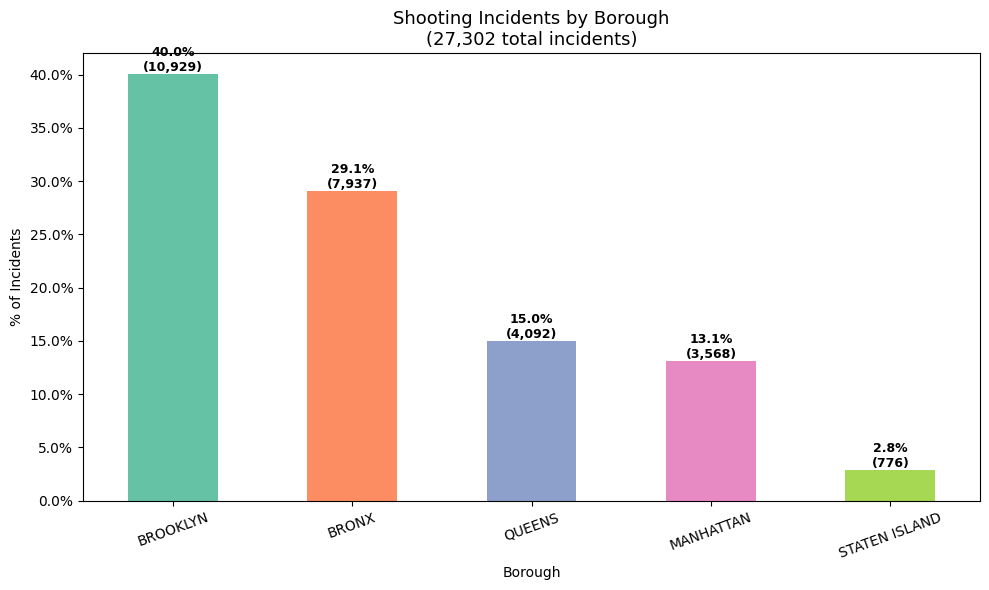


Borough value counts:
BORO
BROOKLYN         10929
BRONX             7937
QUEENS            4092
MANHATTAN         3568
STATEN ISLAND      776
Name: count, dtype: int64


In [ ]:
boro_counts = nysho['BORO'].value_counts()

plt.figure(figsize=(10, 6))
colors = sns.color_palette('Set2', len(boro_counts))
ax = (boro_counts * 100 / len(nysho)).plot(kind='bar', rot=20, color=colors)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Borough')
ax.set_ylabel('% of Incidents')
ax.set_title(f'Shooting Incidents by Borough\n({len(nysho):,} total incidents)', fontsize=13)

total = boro_counts.sum()
for bar, count in zip(ax.patches, boro_counts):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{pct:.1f}%\n({count:,})', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nBorough value counts:")
print(boro_counts)


#### ii. Distribution of Incidents by Hour of Day

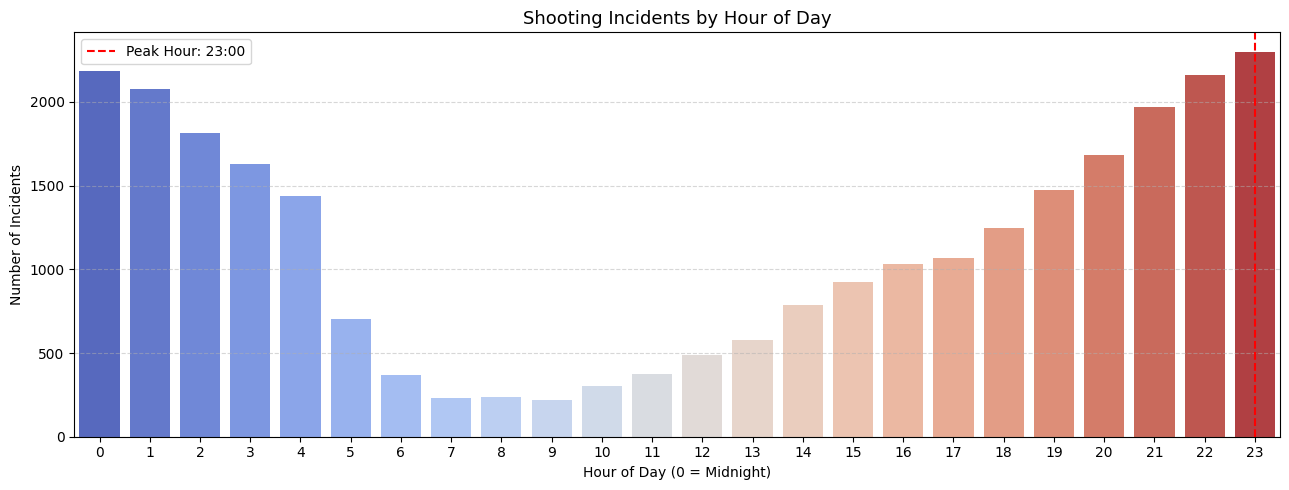

Peak shooting hour: 23:00 with 2,301 incidents


In [ ]:
plt.figure(figsize=(13, 5))
hour_counts = nysho['OCCUR_HOUR'].value_counts().sort_index()

ax = sns.barplot(x=hour_counts.index, y=hour_counts.values, palette='coolwarm')
plt.title('Shooting Incidents by Hour of Day', fontsize=13)
plt.xlabel('Hour of Day (0 = Midnight)')
plt.ylabel('Number of Incidents')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate peak hour
peak_hour = hour_counts.idxmax()
plt.axvline(x=peak_hour, color='red', linestyle='--', linewidth=1.5,
            label=f'Peak Hour: {peak_hour}:00')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Peak shooting hour: {peak_hour}:00 with {hour_counts[peak_hour]:,} incidents")


#### iii. Distribution of Incidents by Victim Sex

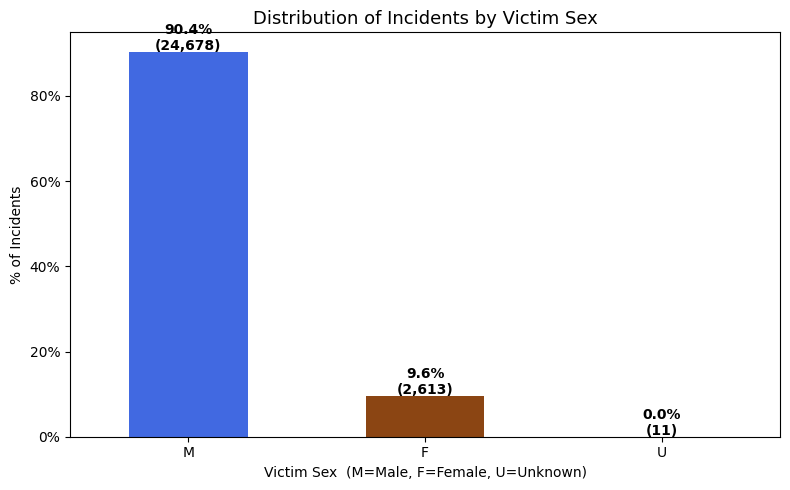

In [ ]:
vic_sex_counts = nysho['VIC_SEX'].value_counts()

plt.figure(figsize=(8, 5))
colors = ['#4169E1', '#8B4513', '#888888']
ax = (vic_sex_counts * 100 / len(nysho)).plot(kind='bar', rot=0, color=colors)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Victim Sex  (M=Male, F=Female, U=Unknown)')
ax.set_ylabel('% of Incidents')
ax.set_title('Distribution of Incidents by Victim Sex', fontsize=13)

total = vic_sex_counts.sum()
for bar, count in zip(ax.patches, vic_sex_counts):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{pct:.1f}%\n({count:,})', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


#### iv. Distribution of Incidents by Victim Age Group

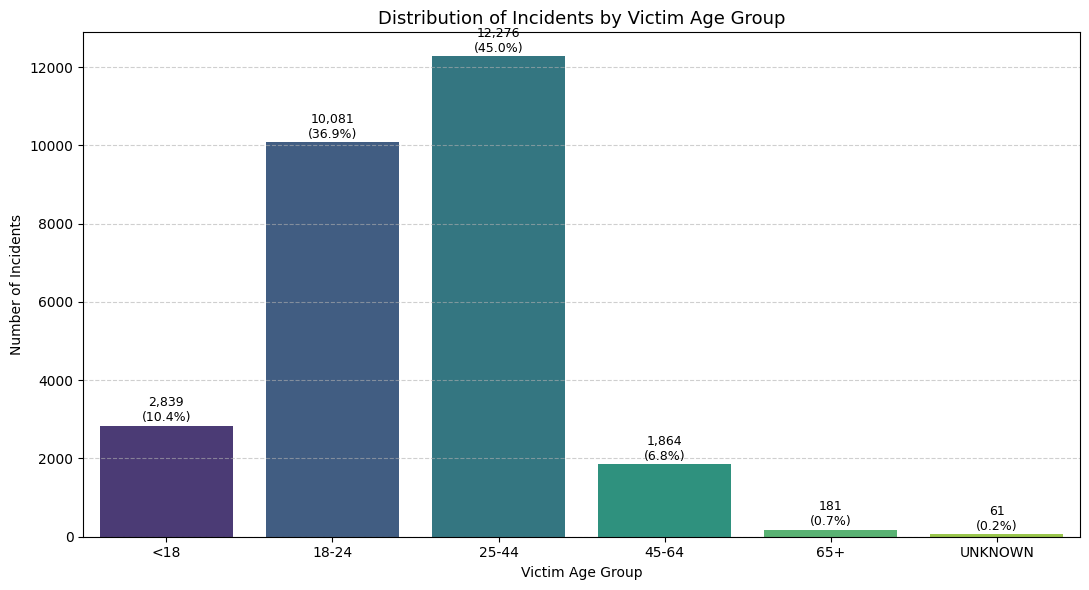

In [ ]:
vic_age_counts = nysho['VIC_AGE_GROUP'].value_counts()

# Define a sensible order
age_order = ['<18', '18-24', '25-44', '45-64', '65+', 'UNKNOWN']
vic_age_ordered = vic_age_counts.reindex([a for a in age_order if a in vic_age_counts.index])

plt.figure(figsize=(11, 6))
ax = sns.barplot(x=vic_age_ordered.index, y=vic_age_ordered.values, palette='viridis')
plt.title('Distribution of Incidents by Victim Age Group', fontsize=13)
plt.xlabel('Victim Age Group')
plt.ylabel('Number of Incidents')
plt.grid(axis='y', linestyle='--', alpha=0.6)

total = vic_age_ordered.sum()
for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 30,
            f'{int(h):,}\n({h/total*100:.1f}%)', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


#### v. Distribution of Incidents by Perpetrator Age Group

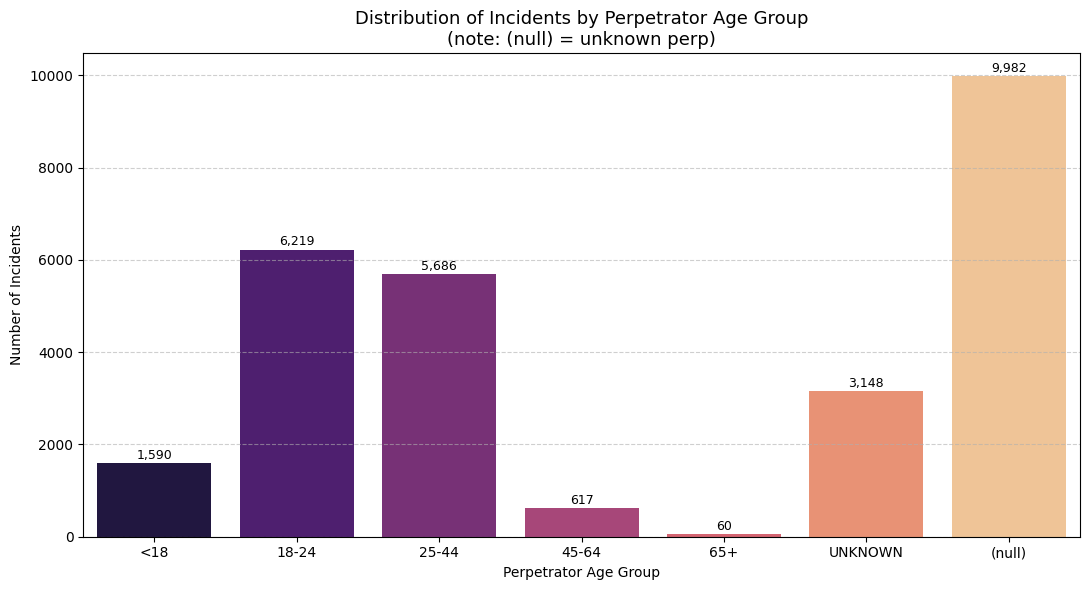

In [ ]:
perp_age_counts = nysho['PERP_AGE_GROUP'].value_counts()
perp_age_ordered = perp_age_counts.reindex(
    [a for a in ['<18','18-24','25-44','45-64','65+','UNKNOWN','(null)'] if a in perp_age_counts.index])

plt.figure(figsize=(11, 6))
ax = sns.barplot(x=perp_age_ordered.index, y=perp_age_ordered.values, palette='magma')
plt.title('Distribution of Incidents by Perpetrator Age Group\n(note: (null) = unknown perp)', fontsize=13)
plt.xlabel('Perpetrator Age Group')
plt.ylabel('Number of Incidents')
plt.grid(axis='y', linestyle='--', alpha=0.6)

total = perp_age_ordered.sum()
for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 30,
            f'{int(h):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


#### vi. Victim Race Distribution

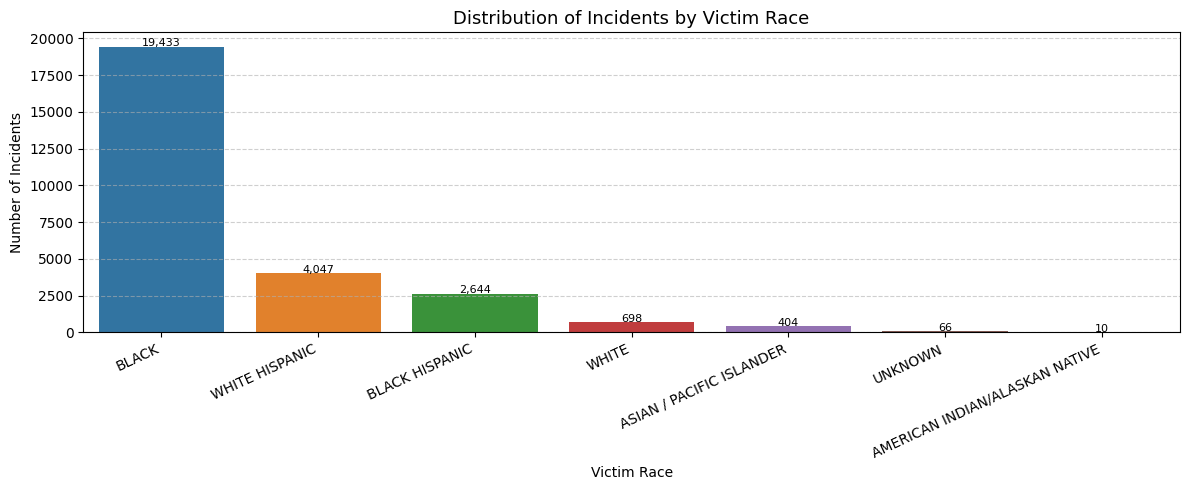

In [ ]:
vic_race_counts = nysho['VIC_RACE'].value_counts()

plt.figure(figsize=(12, 5))
ax = sns.barplot(x=vic_race_counts.index, y=vic_race_counts.values, palette='tab10')
plt.title('Distribution of Incidents by Victim Race', fontsize=13)
plt.xlabel('Victim Race')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 20,
            f'{int(h):,}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


#### vii. Yearly Trend of Shooting Incidents

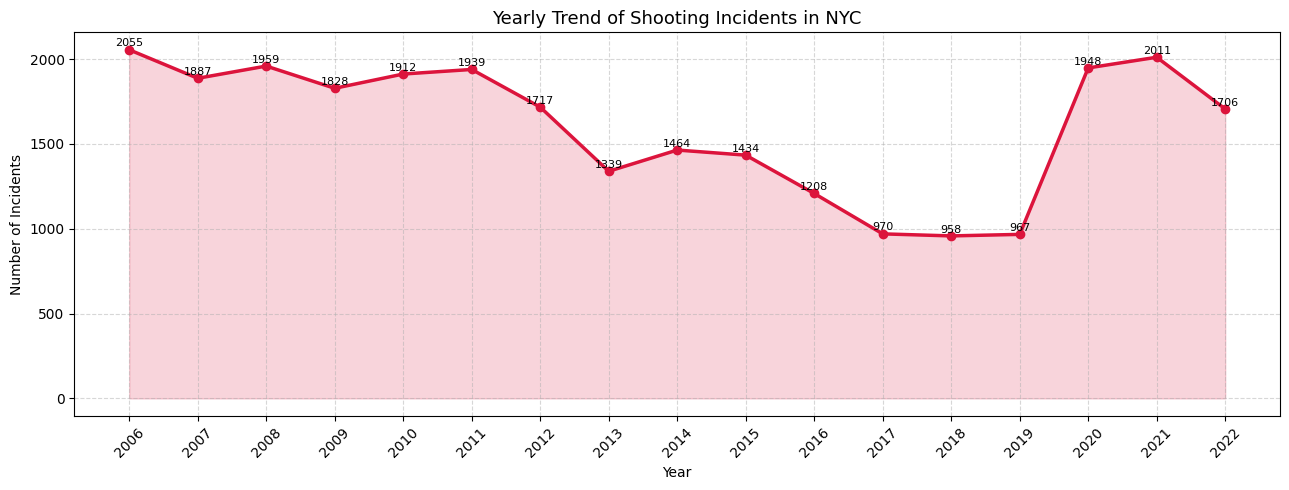

In [ ]:
yearly = nysho['OCCUR_YEAR'].value_counts().sort_index()

plt.figure(figsize=(13, 5))
plt.plot(yearly.index, yearly.values, marker='o', linewidth=2.5, color='crimson')
plt.fill_between(yearly.index, yearly.values, alpha=0.18, color='crimson')

for x, y in zip(yearly.index, yearly.values):
    plt.text(x, y + 20, str(y), ha='center', fontsize=8)

plt.title('Yearly Trend of Shooting Incidents in NYC', fontsize=13)
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.xticks(yearly.index, rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#### viii. Statistical Murder Flag Distribution

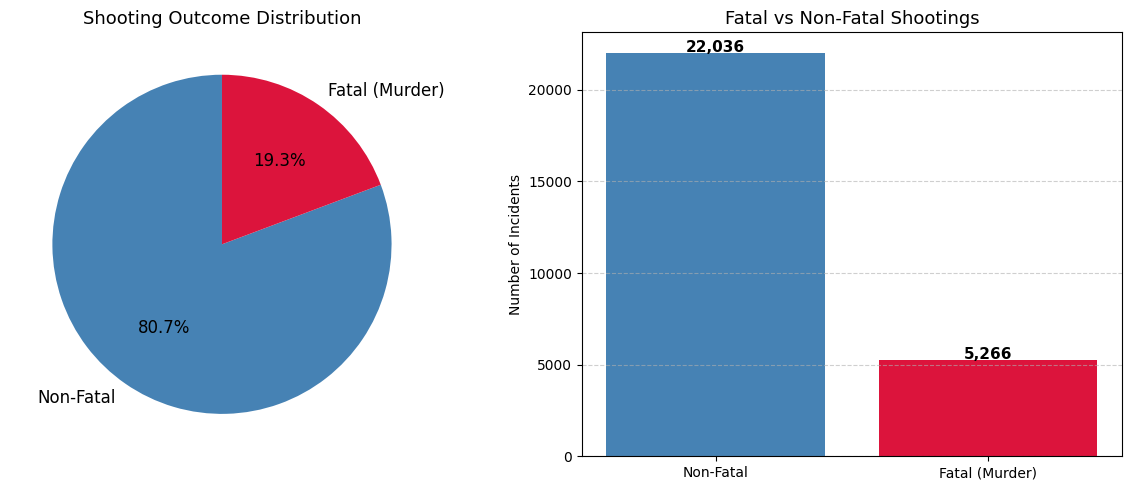

Murder rate: 19.3%


In [ ]:
murder_counts = nysho['STATISTICAL_MURDER_FLAG'].value_counts()
labels = ['Non-Fatal', 'Fatal (Murder)']
colors = ['steelblue', 'crimson']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.pie(murder_counts.values, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
ax1.set_title('Shooting Outcome Distribution', fontsize=13)

ax2.bar(labels, murder_counts.values, color=colors)
ax2.set_ylabel('Number of Incidents')
ax2.set_title('Fatal vs Non-Fatal Shootings', fontsize=13)
for i, (bar, cnt) in enumerate(zip(ax2.patches, murder_counts.values)):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f'{cnt:,}', ha='center', fontsize=11, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
print(f"Murder rate: {murder_counts[1] / murder_counts.sum() * 100:.1f}%")


#### ix. Jurisdiction Code Distribution

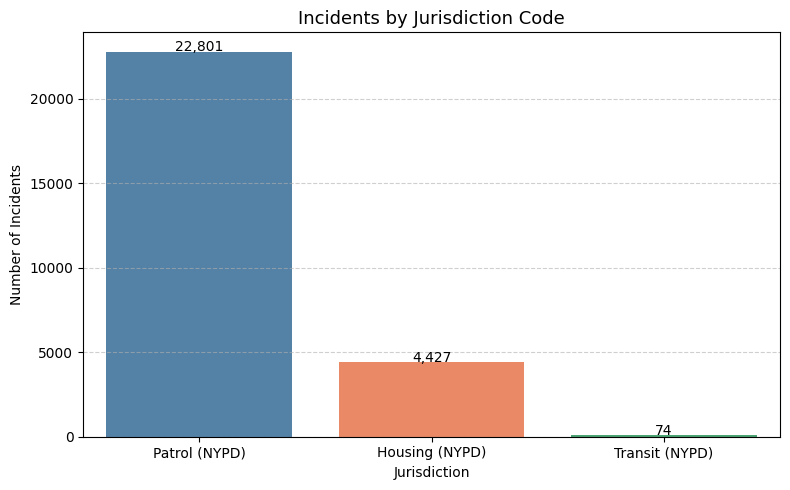

In [ ]:
juris_map  = {0: 'Patrol (NYPD)', 1: 'Transit (NYPD)', 2: 'Housing (NYPD)'}
juris_counts = nysho['JURISDICTION_CODE'].map(juris_map).value_counts()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=juris_counts.index, y=juris_counts.values,
                 palette=['steelblue', 'coral', 'mediumseagreen'])
plt.title('Incidents by Jurisdiction Code', fontsize=13)
plt.xlabel('Jurisdiction')
plt.ylabel('Number of Incidents')
plt.grid(axis='y', linestyle='--', alpha=0.6)
for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 20,
            f'{int(h):,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### 6.2 Bivariate Analysis

#### i. Shootings by Borough and Murder Flag

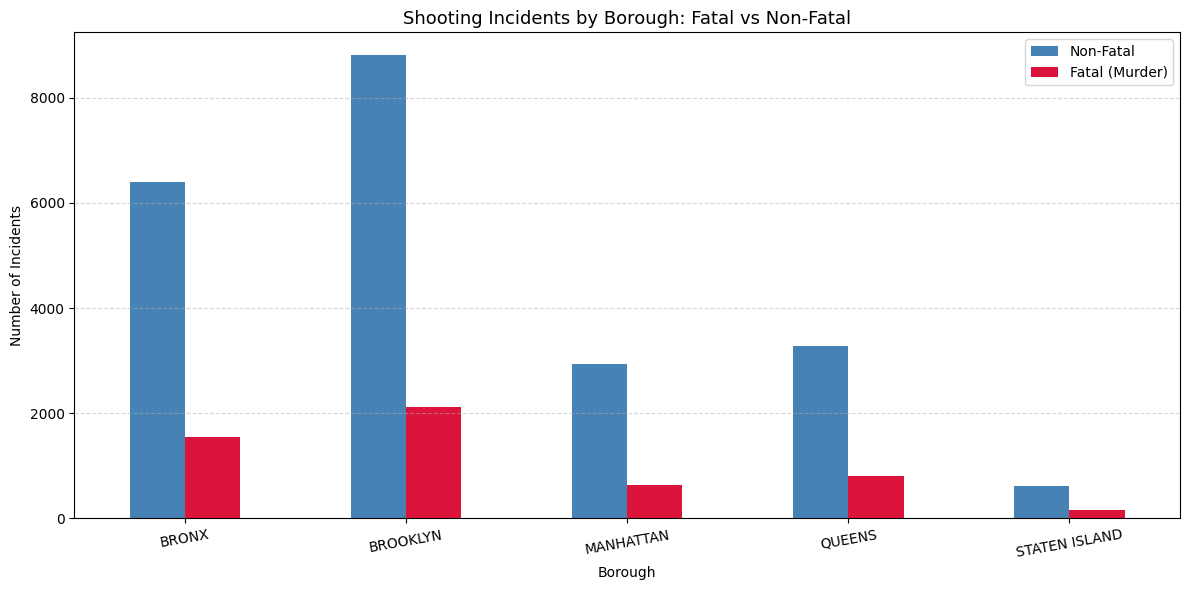


Murder rate by Borough:


,Total,Murders,Murder Rate %
BORO,,,
BRONX,7937,1542,19.4
BROOKLYN,10929,2122,19.4
MANHATTAN,3568,630,17.7
QUEENS,4092,810,19.8
STATEN ISLAND,776,162,20.9


In [ ]:
murder_boro = nysho.groupby('BORO')['STATISTICAL_MURDER_FLAG'].agg(['sum', 'count'])
murder_boro.columns = ['Murders', 'Total']
murder_boro['Non-Fatal'] = murder_boro['Total'] - murder_boro['Murders']
murder_boro['Murder Rate %'] = (murder_boro['Murders'] / murder_boro['Total'] * 100).round(1)

murder_boro[['Non-Fatal', 'Murders']].plot(
    kind='bar', figsize=(12, 6),
    color=['steelblue', 'crimson'], rot=10)
plt.title('Shooting Incidents by Borough: Fatal vs Non-Fatal', fontsize=13)
plt.xlabel('Borough')
plt.ylabel('Number of Incidents')
plt.legend(['Non-Fatal', 'Fatal (Murder)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nMurder rate by Borough:")
display(murder_boro[['Total', 'Murders', 'Murder Rate %']])


#### ii. Shooting Incidents Heatmap: Day of Week vs Hour of Day

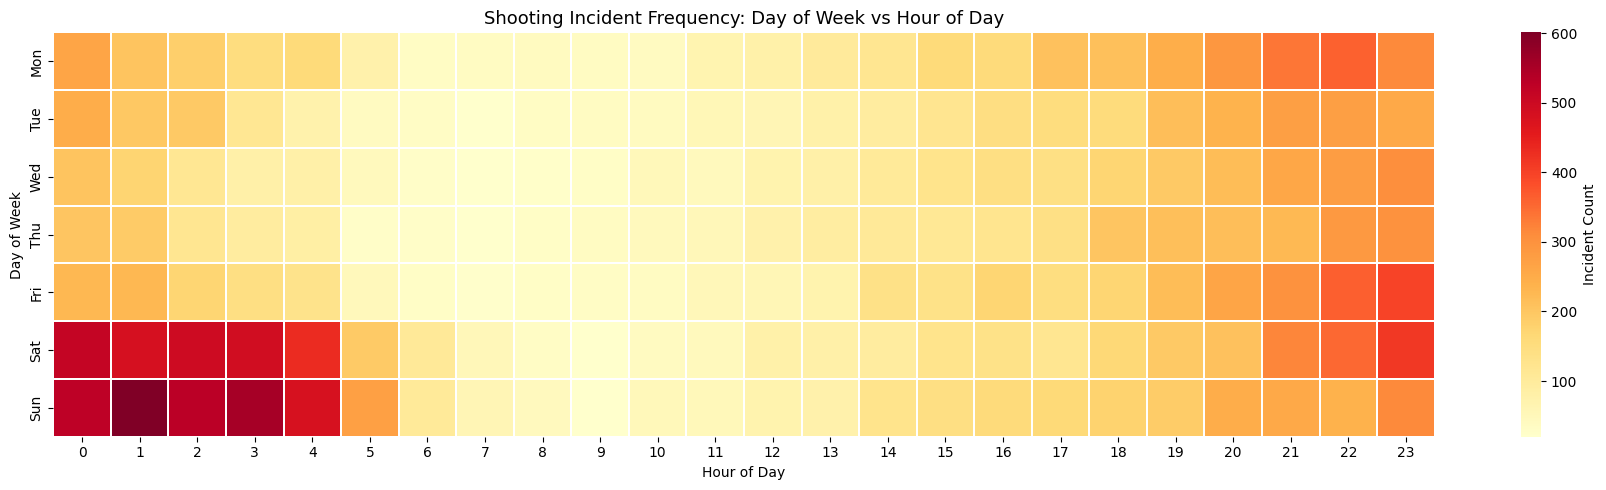

In [ ]:
pivot = nysho.pivot_table(index='OCCUR_DAY_OF_WEEK', columns='OCCUR_HOUR',
                          values='STATISTICAL_MURDER_FLAG', aggfunc='count', fill_value=0)
pivot.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(18, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, annot=False,
            cbar_kws={'label': 'Incident Count'})
plt.title('Shooting Incident Frequency: Day of Week vs Hour of Day', fontsize=13)
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()


#### iii. Victim Age Group vs Perpetrator Age Group

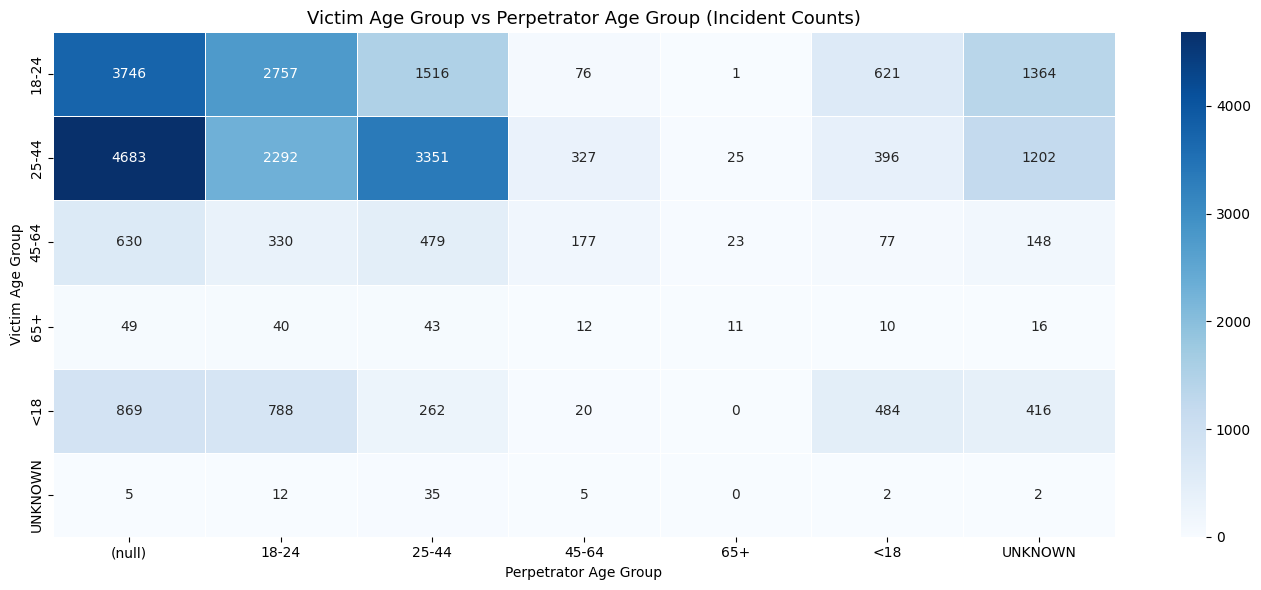

In [ ]:
cross_tab = pd.crosstab(nysho['VIC_AGE_GROUP'], nysho['PERP_AGE_GROUP'])

plt.figure(figsize=(14, 6))
sns.heatmap(cross_tab, cmap='Blues', annot=True, fmt='d', linewidths=0.5)
plt.title('Victim Age Group vs Perpetrator Age Group (Incident Counts)', fontsize=13)
plt.xlabel('Perpetrator Age Group')
plt.ylabel('Victim Age Group')
plt.tight_layout()
plt.show()


#### iv. Victim Race Distribution by Borough

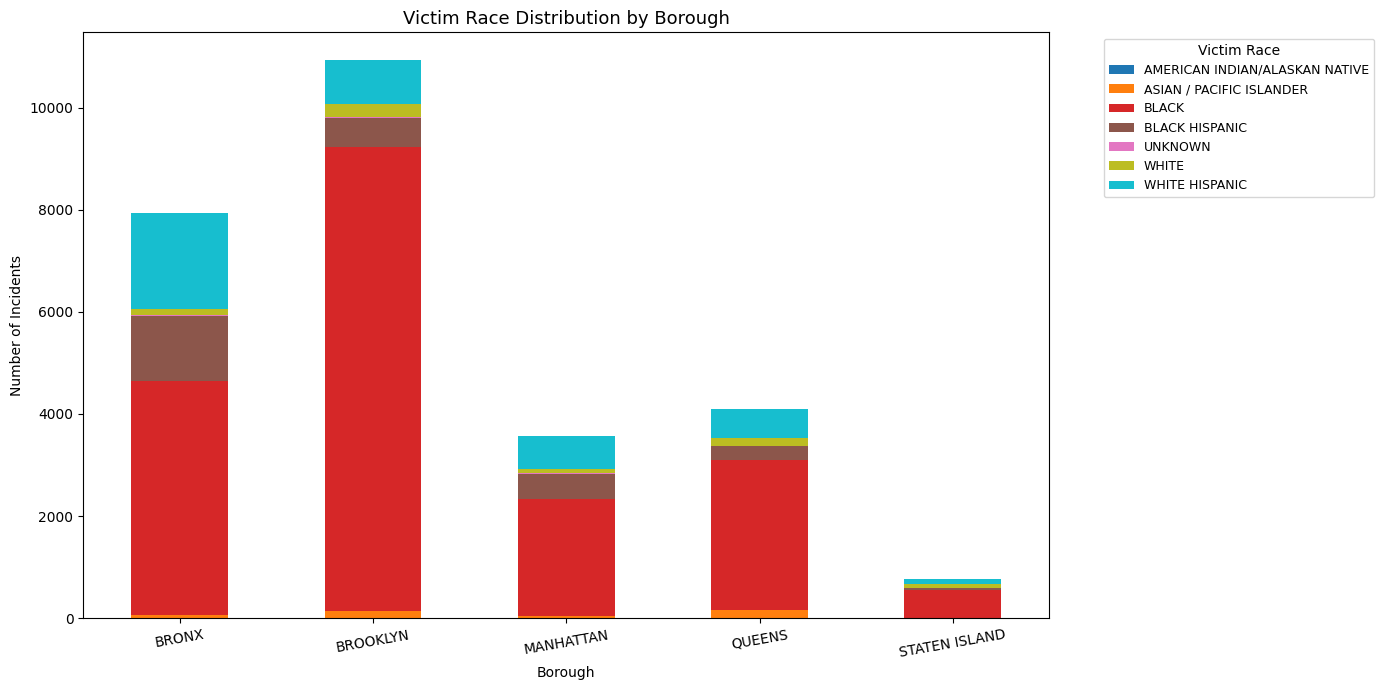

In [ ]:
vic_race_boro = nysho.groupby(['BORO', 'VIC_RACE']).size().unstack(fill_value=0)
vic_race_boro.plot(kind='bar', stacked=True, figsize=(14, 7),
                   colormap='tab10', rot=10)
plt.title('Victim Race Distribution by Borough', fontsize=13)
plt.xlabel('Borough')
plt.ylabel('Number of Incidents')
plt.legend(title='Victim Race', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


#### v. Monthly Shooting Trend by Borough

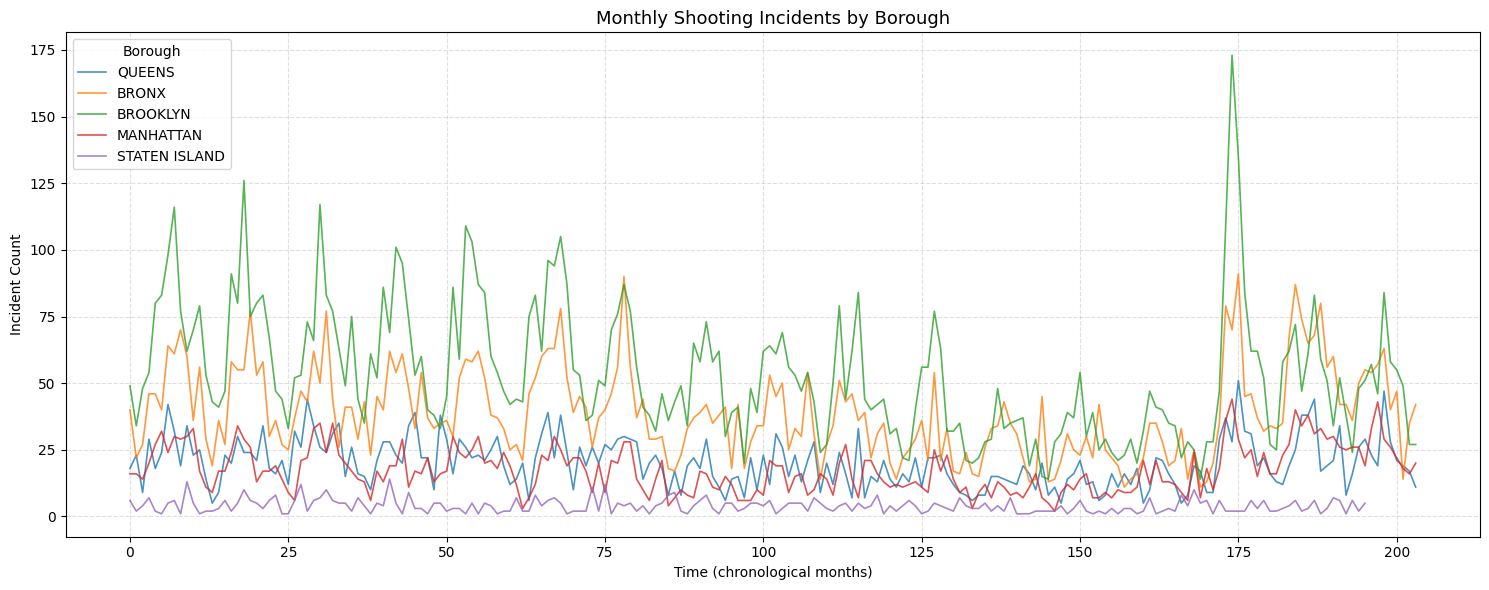

In [ ]:
monthly_boro = nysho.groupby(['OCCUR_YEAR', 'OCCUR_MONTH', 'BORO']).size().reset_index(name='count')
monthly_boro['period'] = monthly_boro['OCCUR_YEAR'] * 100 + monthly_boro['OCCUR_MONTH']

plt.figure(figsize=(15, 6))
for boro in nysho['BORO'].unique():
    subset = monthly_boro[monthly_boro['BORO'] == boro]
    plt.plot(range(len(subset)), subset['count'], label=boro, linewidth=1.2, alpha=0.8)

plt.title('Monthly Shooting Incidents by Borough', fontsize=13)
plt.xlabel('Time (chronological months)')
plt.ylabel('Incident Count')
plt.legend(title='Borough', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## 7. Feature Engineering

### 7.1 Label Encoding of Categorical Variables




In [ ]:
categorical_cols = ['BORO', 'PERP_AGE_GROUP', 'PERP_SEX', 'PERP_RACE',
                    'VIC_AGE_GROUP', 'VIC_SEX', 'VIC_RACE',
                    'LOC_OF_OCCUR_DESC', 'LOC_CLASSFCTN_DESC', 'LOCATION_DESC']

nyshoN = nysho.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    nyshoN[col] = le.fit_transform(nyshoN[col])
    label_encoders[col] = le
    print(f"Column '{col}' encoded. Unique values: {len(le.classes_)}")
    for label, value in zip(le.classes_, le.transform(le.classes_)):
        print(f"    {label!r:45s} -> {value}")
    print()

print(f"Shape after encoding: {nyshoN.shape}")

Column 'BORO' encoded. Unique values: 5
    'BRONX'                                       -> 0
    'BROOKLYN'                                    -> 1
    'MANHATTAN'                                   -> 2
    'QUEENS'                                      -> 3
    'STATEN ISLAND'                               -> 4

Column 'PERP_AGE_GROUP' encoded. Unique values: 7
    '(null)'                                      -> 0
    '18-24'                                       -> 1
    '25-44'                                       -> 2
    '45-64'                                       -> 3
    '65+'                                         -> 4
    '<18'                                         -> 5
    'UNKNOWN'                                     -> 6

Column 'PERP_SEX' encoded. Unique values: 4
    '(null)'                                      -> 0
    'F'                                           -> 1
    'M'                                           -> 2
    'U'                                

### 7.2 Select Features for Clustering

In [ ]:
# Select the 16 most informative features for clustering
# LOC_OF_OCCUR_DESC and LOC_CLASSFCTN_DESC are now included (valid INSIDE/OUTSIDE, STREET/HOUSING etc. values)
# Excludes raw coordinate columns and LOCATION_DESC (>54% missing, too sparse)
feature_cols = [
    'BORO', 'PRECINCT', 'JURISDICTION_CODE', 'STATISTICAL_MURDER_FLAG',
    'PERP_AGE_GROUP', 'PERP_SEX', 'PERP_RACE',
    'VIC_AGE_GROUP', 'VIC_SEX', 'VIC_RACE',
    'LOC_OF_OCCUR_DESC', 'LOC_CLASSFCTN_DESC',
    'OCCUR_DAY_OF_WEEK', 'OCCUR_MONTH', 'OCCUR_HOUR', 'OCCUR_YEAR'
]

numeric_features = nyshoN[feature_cols].copy()
print(f"Feature matrix: {numeric_features.shape[0]:,} samples × {numeric_features.shape[1]} features")
numeric_features.head()

Feature matrix: 27,302 samples × 16 features


,BORO,PRECINCT,JURISDICTION_CODE,STATISTICAL_MURDER_FLAG,PERP_AGE_GROUP,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,LOC_OF_OCCUR_DESC,LOC_CLASSFCTN_DESC,OCCUR_DAY_OF_WEEK,OCCUR_MONTH,OCCUR_HOUR,OCCUR_YEAR
0,3,105,0.0,0,0,0,0,0,1,2,0,0,3,5,21,2021
1,0,40,0.0,0,0,0,0,0,1,2,0,0,4,6,17,2014
2,3,108,0.0,1,0,0,0,1,1,5,0,0,5,11,3,2015
3,0,44,0.0,0,0,0,0,4,1,6,0,0,4,10,18,2015
4,0,47,0.0,1,2,2,3,2,1,2,0,0,3,2,22,2009


## 8. Handling Missing Data (Imputation)

In [ ]:
# Verify remaining missing values in feature set
missing = numeric_features.isnull().sum()
if missing.sum() == 0:
    print("No missing values in feature matrix — no imputation needed.")
else:
    print("Missing values found:")
    print(missing[missing > 0])
    numeric_features = numeric_features.fillna(numeric_features.median())
    print("Filled with column medians.")


No missing values in feature matrix — no imputation needed.


### 8.1 Feature Scaling

In [ ]:
# StandardScaler — zero mean, unit variance
# Essential before PCA and distance-based algorithms (K-Means, DBSCAN)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_features)
print(f"Scaled feature matrix shape: {scaled_features.shape}")
print(f"Feature means (should be ~0): {scaled_features.mean(axis=0).round(3)}")


Scaled feature matrix shape: (27302, 16)
Feature means (should be ~0): [-0.  0. -0.  0.  0.  0.  0.  0.  0.  0. -0. -0. -0. -0. -0. -0.]


### 8.2 PCA — Dimensionality Reduction to 3 Components

In [ ]:
pca = PCA(n_components=3)
principal_components = pca.fit_transform(scaled_features)

print("Explained variance ratio per component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"Total variance explained by 3 PCs: {pca.explained_variance_ratio_.sum()*100:.2f}%")

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])
pca_df.head()


Explained variance ratio per component:
  PC1: 0.1699 (16.99%)
  PC2: 0.1320 (13.20%)
  PC3: 0.1010 (10.10%)
Total variance explained by 3 PCs: 40.29%


,PC1,PC2,PC3
0,-2.118432,-0.943578,1.976456
1,-1.576935,-0.985512,-1.461411
2,-1.545632,-1.287648,1.896088
3,-1.292488,-0.542708,-1.932648
4,0.999920,0.053687,-1.183472


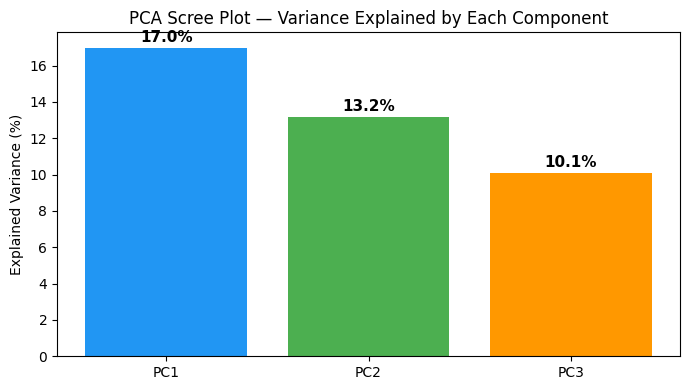

In [ ]:
# Scree Plot
plt.figure(figsize=(7, 4))
bars = plt.bar(['PC1', 'PC2', 'PC3'], pca.explained_variance_ratio_ * 100,
               color=['#2196F3', '#4CAF50', '#FF9800'])
plt.ylabel('Explained Variance (%)')
plt.title('PCA Scree Plot — Variance Explained by Each Component', fontsize=12)
for bar, val in zip(bars, pca.explained_variance_ratio_ * 100):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Clustering Model Development

### 9.1 K-Means Clustering

K-Means partitions data into **K** non-overlapping clusters by minimising within-cluster sum of squares (WCSS / inertia). We use the **Elbow Method** and **Silhouette Score** to determine the optimal K.


#### Finding Optimal K — Elbow + Silhouette

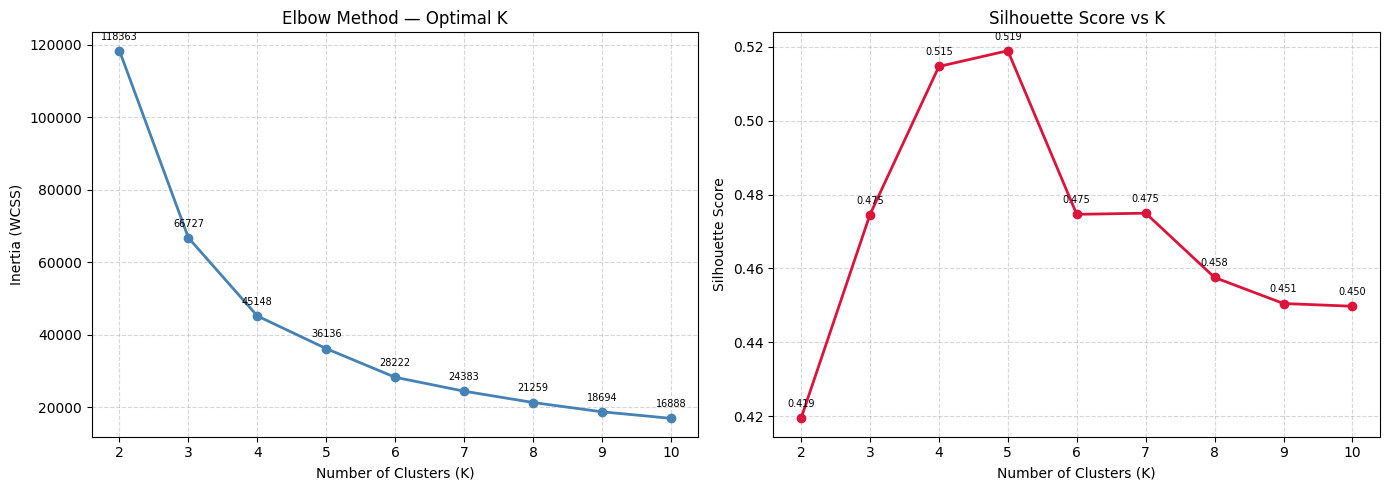

In [ ]:
inertia_values    = []
silhouette_scores = []
db_scores         = []
ch_scores         = []
k_range           = range(2, 11)

for K in k_range:
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    km.fit(principal_components)
    inertia_values.append(km.inertia_)
    silhouette_scores.append(silhouette_score(principal_components, km.labels_))
    db_scores.append(davies_bouldin_score(principal_components, km.labels_))
    ch_scores.append(calinski_harabasz_score(principal_components, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia_values, marker='o', linewidth=2, color='steelblue')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method — Optimal K')
axes[0].grid(True, linestyle='--', alpha=0.5)
for k, v in zip(k_range, inertia_values):
    axes[0].annotate(f'{v:.0f}', (k, v), textcoords='offset points', xytext=(0, 8),
                     fontsize=7, ha='center')

axes[1].plot(k_range, silhouette_scores, marker='o', linewidth=2, color='crimson')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
axes[1].grid(True, linestyle='--', alpha=0.5)
for k, v in zip(k_range, silhouette_scores):
    axes[1].annotate(f'{v:.3f}', (k, v), textcoords='offset points', xytext=(0, 8), fontsize=7, ha='center')

plt.tight_layout()
plt.show()


In [ ]:
# Full evaluation table
eval_df = pd.DataFrame({
    'K': list(k_range),
    'Inertia': [round(v, 2) for v in inertia_values],
    'Silhouette Score': [round(v, 4) for v in silhouette_scores],
    'Davies-Bouldin Score': [round(v, 4) for v in db_scores],
    'Calinski-Harabasz Score': [round(v, 2) for v in ch_scores]
})
display(eval_df)

best_k_sil = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest K by Silhouette Score: {best_k_sil} (score = {max(silhouette_scores):.4f})")


,K,Inertia,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,2,118363.13,0.4195,1.1719,13292.50
1,3,66726.65,0.4746,0.7399,22351.69
2,4,45148.39,0.5146,0.7301,26371.14
3,5,36136.08,0.5189,0.6168,26412.10
4,6,28221.85,0.4746,0.7468,28584.99
5,7,24383.06,0.4750,0.7068,28286.30
6,8,21258.83,0.4576,0.7358,28380.70
7,9,18694.49,0.4505,0.8531,28706.29
8,10,16887.61,0.4498,0.8697,28570.26



Best K by Silhouette Score: 5 (score = 0.5189)


#### Fit Final K-Means Model (K=7)

In [ ]:
OPTIMAL_K = 7  # confirmed by elbow inflection + highest silhouette

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
pca_df['KMeans_Cluster'] = kmeans.fit_predict(principal_components)

km_sil = silhouette_score(principal_components, pca_df['KMeans_Cluster'])
km_db  = davies_bouldin_score(principal_components, pca_df['KMeans_Cluster'])
km_ch  = calinski_harabasz_score(principal_components, pca_df['KMeans_Cluster'])

print(f"K-Means (K={OPTIMAL_K})")
print(f"  Silhouette Score      : {km_sil:.4f}  (higher = better)")
print(f"  Davies-Bouldin Score  : {km_db:.4f}  (lower  = better)")
print(f"  Calinski-Harabasz     : {km_ch:.2f}  (higher = better)")


K-Means (K=7)
  Silhouette Score      : 0.4750  (higher = better)
  Davies-Bouldin Score  : 0.7068  (lower  = better)
  Calinski-Harabasz     : 28286.30  (higher = better)


#### 3D PCA Scatter — K-Means Clusters

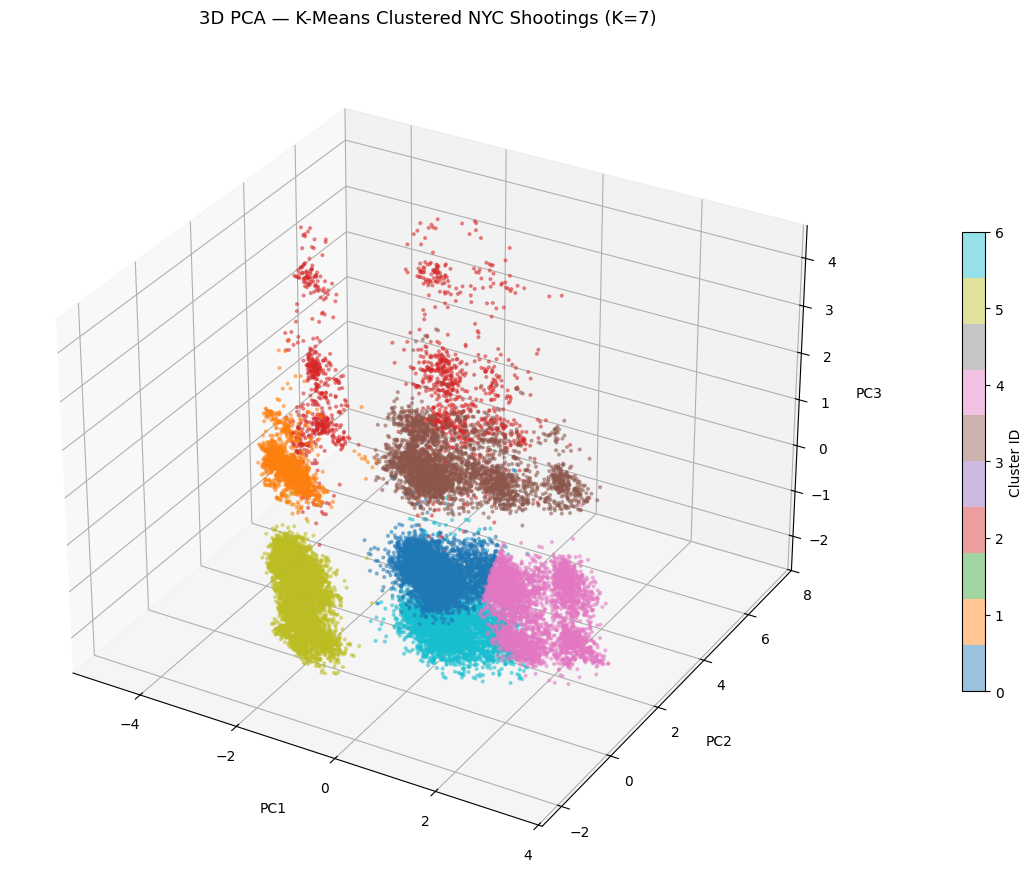

In [ ]:
fig = plt.figure(figsize=(12, 9))
ax  = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_df['PC1'], pca_df['PC2'], pca_df['PC3'],
    c=pca_df['KMeans_Cluster'], cmap='tab10',
    marker='o', alpha=0.45, s=4
)

ax.set_xlabel('PC1', labelpad=10)
ax.set_ylabel('PC2', labelpad=10)
ax.set_zlabel('PC3', labelpad=10)
ax.set_title(f'3D PCA — K-Means Clustered NYC Shootings (K={OPTIMAL_K})', fontsize=13, pad=15)

cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.55)
cbar.set_label('Cluster ID', fontsize=10)
plt.tight_layout()
plt.show()


#### Cluster Size Distribution — K-Means

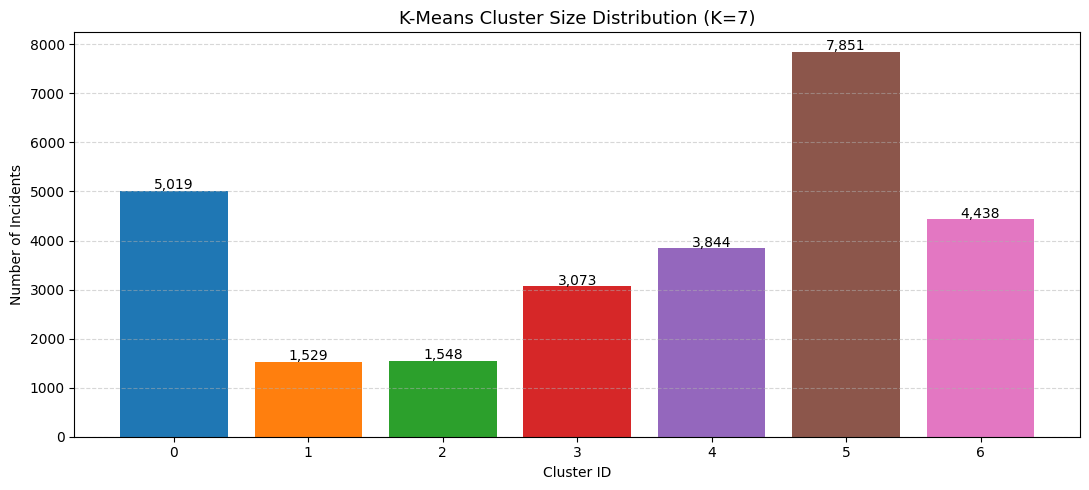

In [ ]:
cluster_sizes = pca_df['KMeans_Cluster'].value_counts().sort_index()
colors_km = sns.color_palette('tab10', OPTIMAL_K)

plt.figure(figsize=(11, 5))
bars = plt.bar(cluster_sizes.index, cluster_sizes.values, color=colors_km)
plt.title(f'K-Means Cluster Size Distribution (K={OPTIMAL_K})', fontsize=13)
plt.xlabel('Cluster ID')
plt.ylabel('Number of Incidents')
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar, cnt in zip(bars, cluster_sizes.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f'{cnt:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


#### Mean Feature Profile per K-Means Cluster

In [ ]:
profile_df = numeric_features.copy()
profile_df['KMeans_Cluster'] = pca_df['KMeans_Cluster'].values

cluster_profile = profile_df.groupby('KMeans_Cluster').mean().round(2)
print("Mean feature values per cluster:")
display(cluster_profile)


Mean feature values per cluster:


,BORO,PRECINCT,JURISDICTION_CODE,STATISTICAL_MURDER_FLAG,PERP_AGE_GROUP,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,LOC_OF_OCCUR_DESC,LOC_CLASSFCTN_DESC,OCCUR_DAY_OF_WEEK,OCCUR_MONTH,OCCUR_HOUR,OCCUR_YEAR
KMeans_Cluster,,,,,,,,,,,,,,,,
0,1.17,67.17,0.35,0.23,1.75,1.97,3.20,1.01,0.89,2.32,0.01,0.01,3.26,6.69,12.66,2012.87
1,3.09,108.28,0.20,0.20,0.01,0.01,0.02,0.90,0.91,2.53,0.01,0.02,3.51,7.00,10.97,2014.97
2,1.24,61.57,0.27,0.18,1.31,1.22,2.34,1.10,0.88,2.85,1.94,5.97,3.13,6.31,12.87,2022.00
3,3.20,109.86,0.22,0.20,2.60,2.06,3.85,1.00,0.89,2.81,0.01,0.01,3.44,6.70,11.35,2012.12
4,0.87,55.72,0.26,0.10,5.12,2.31,4.72,1.22,0.90,3.10,0.00,0.00,3.43,6.74,12.04,2008.41
5,0.81,58.49,0.39,0.18,0.00,0.00,0.00,0.97,0.93,2.59,0.00,0.01,3.37,7.11,11.91,2014.79
6,0.32,41.24,0.38,0.24,1.81,1.97,3.93,1.07,0.90,3.26,0.01,0.02,3.26,6.75,13.24,2013.76


### 9.2 Agglomerative Hierarchical Clustering

Agglomerative clustering builds a hierarchy of clusters bottom-up. We use **Ward linkage**, which minimises total within-cluster variance at each merge step — it tends to produce compact, equally-sized clusters similar to K-Means.


#### Dendrogram (500-sample for readability)

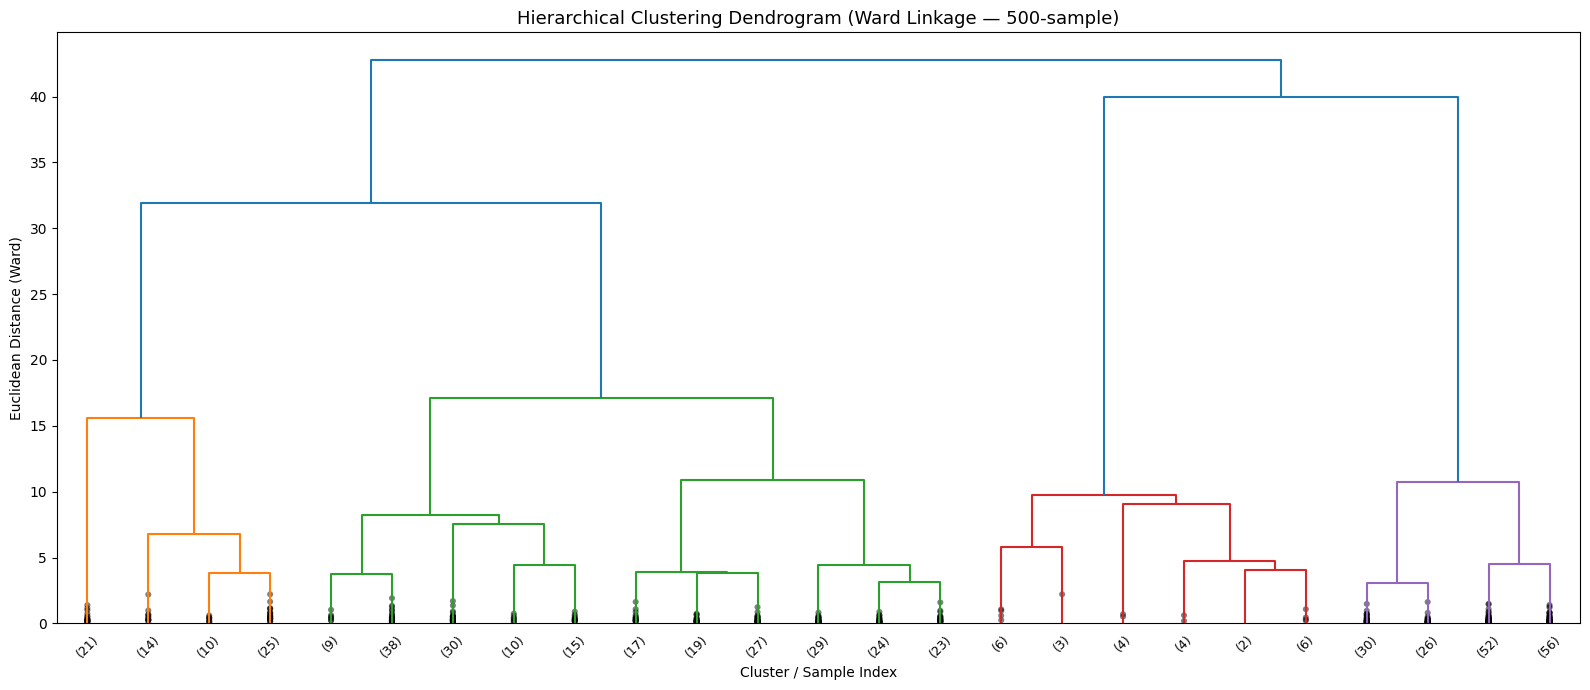

In [ ]:
np.random.seed(42)
sample_idx  = np.random.choice(len(principal_components), size=500, replace=False)
sample_data = principal_components[sample_idx]

linked = linkage(sample_data, method='ward')

plt.figure(figsize=(16, 7))
dendrogram(
    linked,
    truncate_mode='lastp', p=25,
    leaf_rotation=45, leaf_font_size=9,
    show_contracted=True,
    color_threshold=0.7 * max(linked[:, 2])
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage — 500-sample)', fontsize=13)
plt.xlabel('Cluster / Sample Index')
plt.ylabel('Euclidean Distance (Ward)')
plt.tight_layout()
plt.show()


#### Fit Agglomerative Model (n_clusters=7)

In [ ]:
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, metric='euclidean', linkage='ward')
pca_df['Agg_Cluster'] = agg.fit_predict(principal_components)

agg_sil = silhouette_score(principal_components, pca_df['Agg_Cluster'])
agg_db  = davies_bouldin_score(principal_components, pca_df['Agg_Cluster'])
agg_ch  = calinski_harabasz_score(principal_components, pca_df['Agg_Cluster'])

print(f"Agglomerative (K={OPTIMAL_K})")
print(f"  Silhouette Score      : {agg_sil:.4f}")
print(f"  Davies-Bouldin Score  : {agg_db:.4f}")
print(f"  Calinski-Harabasz     : {agg_ch:.2f}")


Agglomerative (K=7)
  Silhouette Score      : 0.4583
  Davies-Bouldin Score  : 0.7376
  Calinski-Harabasz     : 26152.96


#### 3D PCA Scatter — Agglomerative Clusters

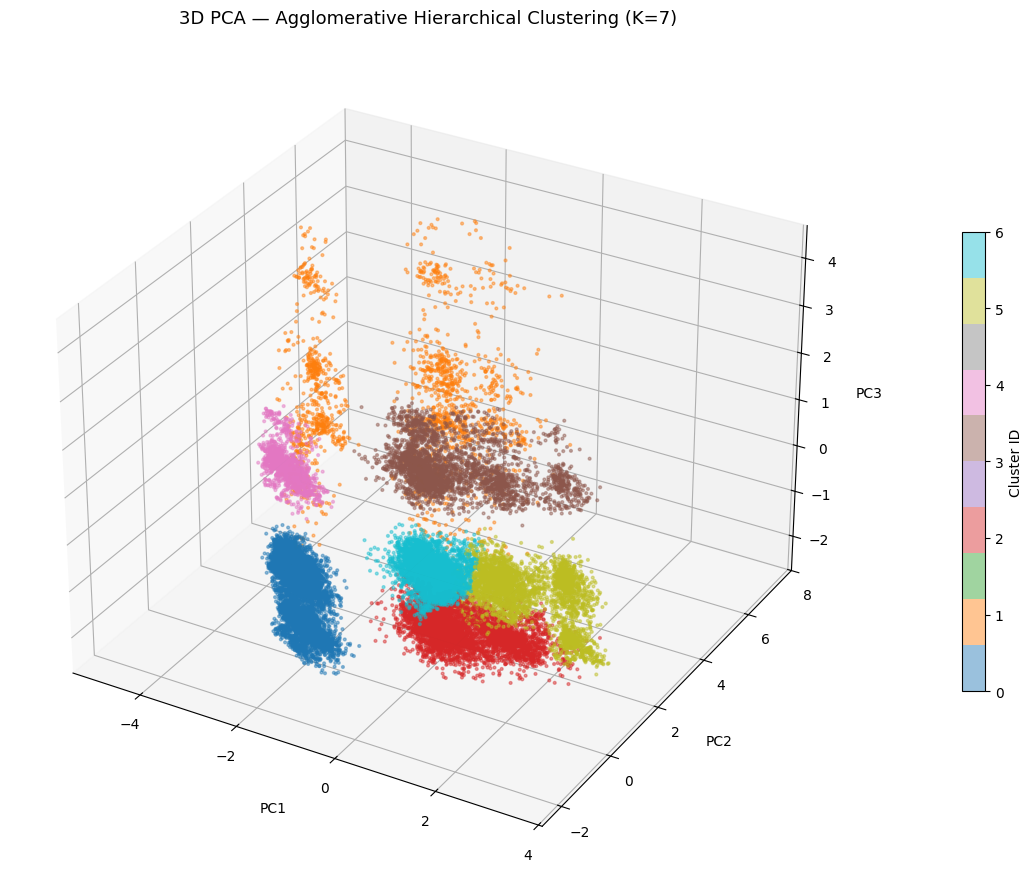

In [ ]:
fig = plt.figure(figsize=(12, 9))
ax  = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_df['PC1'], pca_df['PC2'], pca_df['PC3'],
    c=pca_df['Agg_Cluster'], cmap='tab10',
    marker='o', alpha=0.45, s=4
)

ax.set_xlabel('PC1', labelpad=10)
ax.set_ylabel('PC2', labelpad=10)
ax.set_zlabel('PC3', labelpad=10)
ax.set_title(f'3D PCA — Agglomerative Hierarchical Clustering (K={OPTIMAL_K})', fontsize=13, pad=15)

cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.55)
cbar.set_label('Cluster ID', fontsize=10)
plt.tight_layout()
plt.show()


#### Agglomerative Cluster Size Distribution

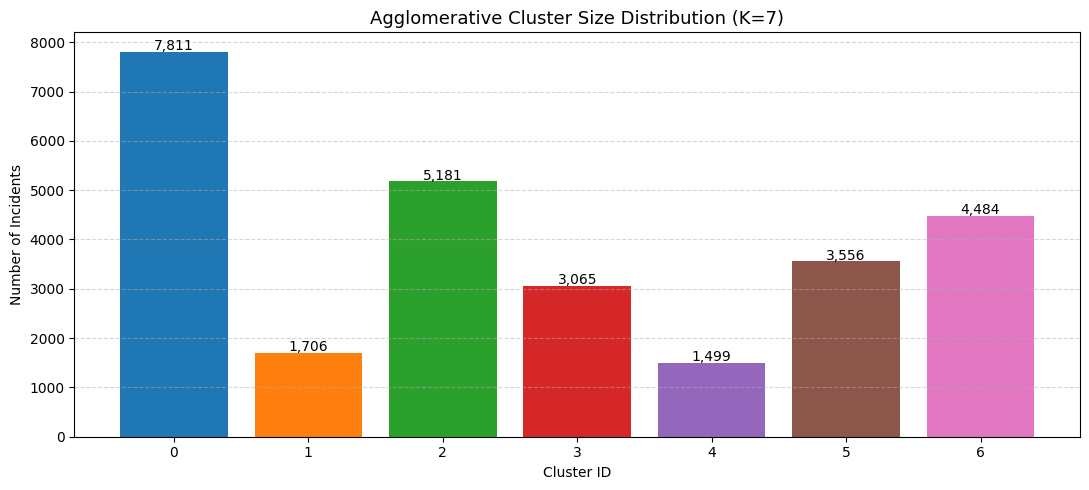

In [ ]:
agg_sizes = pca_df['Agg_Cluster'].value_counts().sort_index()

plt.figure(figsize=(11, 5))
bars = plt.bar(agg_sizes.index, agg_sizes.values, color=sns.color_palette('tab10', OPTIMAL_K))
plt.title(f'Agglomerative Cluster Size Distribution (K={OPTIMAL_K})', fontsize=13)
plt.xlabel('Cluster ID')
plt.ylabel('Number of Incidents')
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar, cnt in zip(bars, agg_sizes.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f'{cnt:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### 9.3 DBSCAN Clustering

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) does not require a pre-specified K. It discovers clusters of arbitrary shape and flags low-density points as **noise** (label = `-1`).

Key parameters:
- `eps` — maximum distance between two points to be neighbours
- `min_samples` — minimum points in a neighbourhood to form a core point


In [ ]:
db = DBSCAN(eps=0.3, min_samples=10).fit(principal_components)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

pca_df['DBSCAN_Cluster'] = db.labels_

n_clusters_db = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise       = list(db.labels_).count(-1)

print(f"DBSCAN Results:")
print(f"  Estimated clusters : {n_clusters_db}")
print(f"  Noise points       : {n_noise:,} ({n_noise / len(db.labels_) * 100:.2f}% of data)")
print(f"\nCluster label distribution:")
print(pd.Series(db.labels_).value_counts().sort_index())


DBSCAN Results:
  Estimated clusters : 15
  Noise points       : 489 (1.79% of data)

Cluster label distribution:
-1       489
 0      1496
 1      7811
 2     13192
 3      3042
 4       570
 5       312
 6        74
 7        83
 8        19
 9        75
 10       70
 11       25
 12       17
 13       10
 14       17
Name: count, dtype: int64


#### DBSCAN — 2D Cluster Plot (PC1 vs PC2)

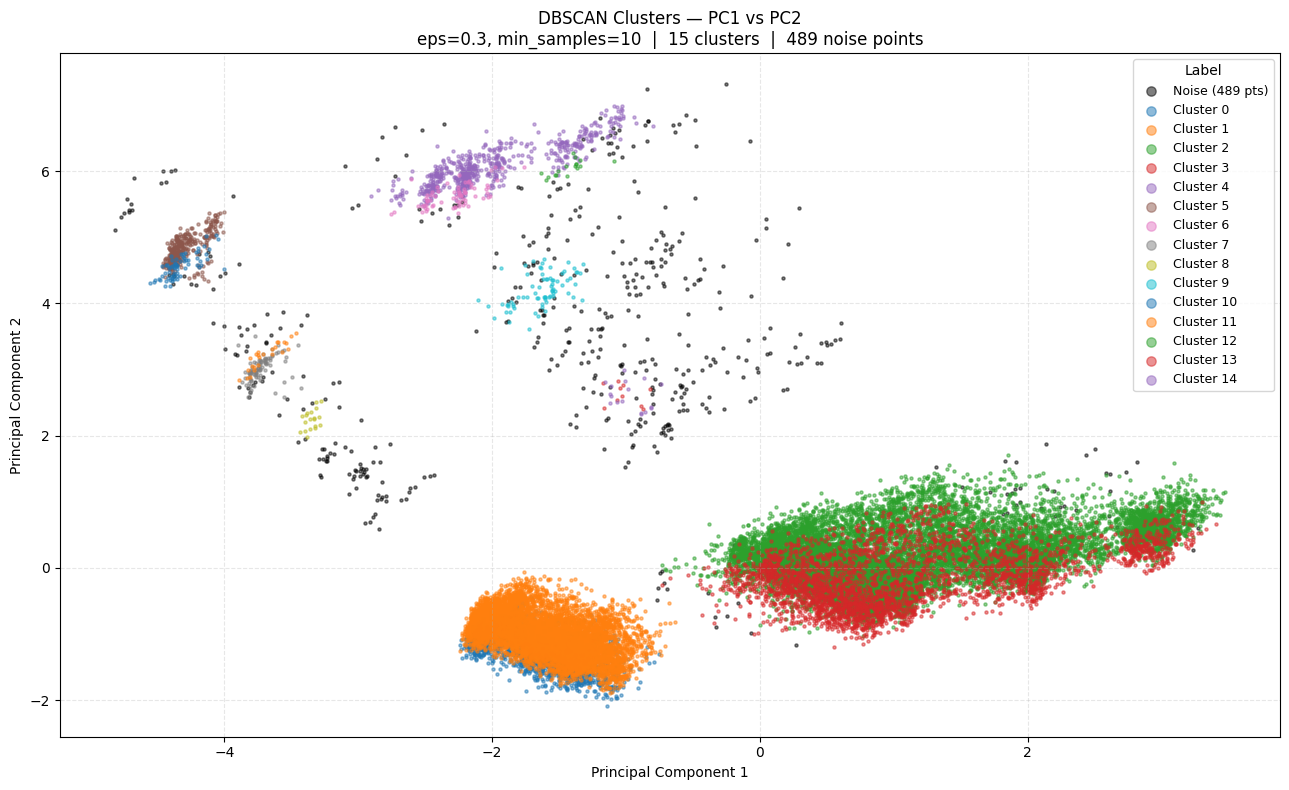

In [ ]:
unique_labels = sorted(set(db.labels_))
palette = sns.color_palette('tab10', n_colors=max(n_clusters_db, 1))

plt.figure(figsize=(13, 8))
for k in unique_labels:
    mask  = db.labels_ == k
    color = 'black' if k == -1 else palette[k % len(palette)]
    label = f'Noise ({n_noise:,} pts)' if k == -1 else f'Cluster {k}'
    plt.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                c=[color], label=label, s=5, alpha=0.5)

plt.title(f'DBSCAN Clusters — PC1 vs PC2\n'
          f'eps=0.3, min_samples=10  |  {n_clusters_db} clusters  |  {n_noise:,} noise points',
          fontsize=12)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(markerscale=3, loc='best', fontsize=9, title='Label')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


#### DBSCAN Evaluation Metrics (non-noise points only)

In [ ]:
non_noise_mask = pca_df['DBSCAN_Cluster'] != -1
n_non_noise    = non_noise_mask.sum()
n_distinct_cl  = len(set(pca_df.loc[non_noise_mask, 'DBSCAN_Cluster']))

if n_non_noise > 0 and n_distinct_cl > 1:
    db_sil = silhouette_score(principal_components[non_noise_mask],
                               pca_df.loc[non_noise_mask, 'DBSCAN_Cluster'])
    db_db  = davies_bouldin_score(principal_components[non_noise_mask],
                                   pca_df.loc[non_noise_mask, 'DBSCAN_Cluster'])
    db_ch  = calinski_harabasz_score(principal_components[non_noise_mask],
                                      pca_df.loc[non_noise_mask, 'DBSCAN_Cluster'])
    print(f"DBSCAN (non-noise: {n_non_noise:,} pts, {n_distinct_cl} clusters)")
    print(f"  Silhouette Score      : {db_sil:.4f}")
    print(f"  Davies-Bouldin Score  : {db_db:.4f}")
    print(f"  Calinski-Harabasz     : {db_ch:.2f}")
else:
    db_sil = db_db = db_ch = None
    print("Insufficient distinct clusters for DBSCAN metric computation.")


DBSCAN (non-noise: 26,813 pts, 15 clusters)
  Silhouette Score      : 0.5182
  Davies-Bouldin Score  : 0.5643
  Calinski-Harabasz     : 9220.55
